## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000002525C56E800> [RTYPES.NILSXP]

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [90]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2009-2023_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [6]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL30,αττικη,EL305,ανατολικη αττικη,24.007270,37.832280,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14005.000000,NaN,14005.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,EL30,αττικη,EL305,ανατολικη αττικη,24.007270,37.832280,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14005.000000,NaN,14005.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.076149
2,EL30,αττικη,EL305,ανατολικη αττικη,24.007270,37.832280,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14005.000000,NaN,14005.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.246532
3,EL30,αττικη,EL305,ανατολικη αττικη,24.007270,37.832280,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14005.000000,NaN,14005.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.275706
4,EL30,αττικη,EL305,ανατολικη αττικη,24.007270,37.832280,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14005.000000,NaN,14005.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.036224


In [7]:
timeline_file.shape

(3418272, 33)

In [8]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5


In [9]:
wnv_file.shape

(336, 4)

In [ ]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [ ]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [ ]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [11]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [12]:
dataset.dtypes

NUTS2_ID               object
NUTS2_NAME             object
NUTS3_ID               object
NUTS3_NAME             object
x                     float64
y                     float64
dt_placement           object
year                    int64
month                   int64
day                     int64
ndvi                  float64
ndmi                  float64
ndwi                  float64
ndbi                  float64
ndvi_mean             float64
ndmi_mean             float64
ndwi_mean             float64
ndbi_mean             float64
ndvi_std              float64
ndmi_std              float64
ndwi_std              float64
ndbi_std              float64
lst_day               float64
lst_night             float64
lst_day_jan_mean      float64
lst_day_feb_mean      float64
lst_day_mar_mean      float64
lst_day_apr_mean      float64
lst_night_jan_mean    float64
lst_night_feb_mean    float64
lst_night_mar_mean    float64
lst_night_apr_mean    float64
rainfall              float64
lst       

In [13]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))


In [16]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [17]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [18]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [19]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

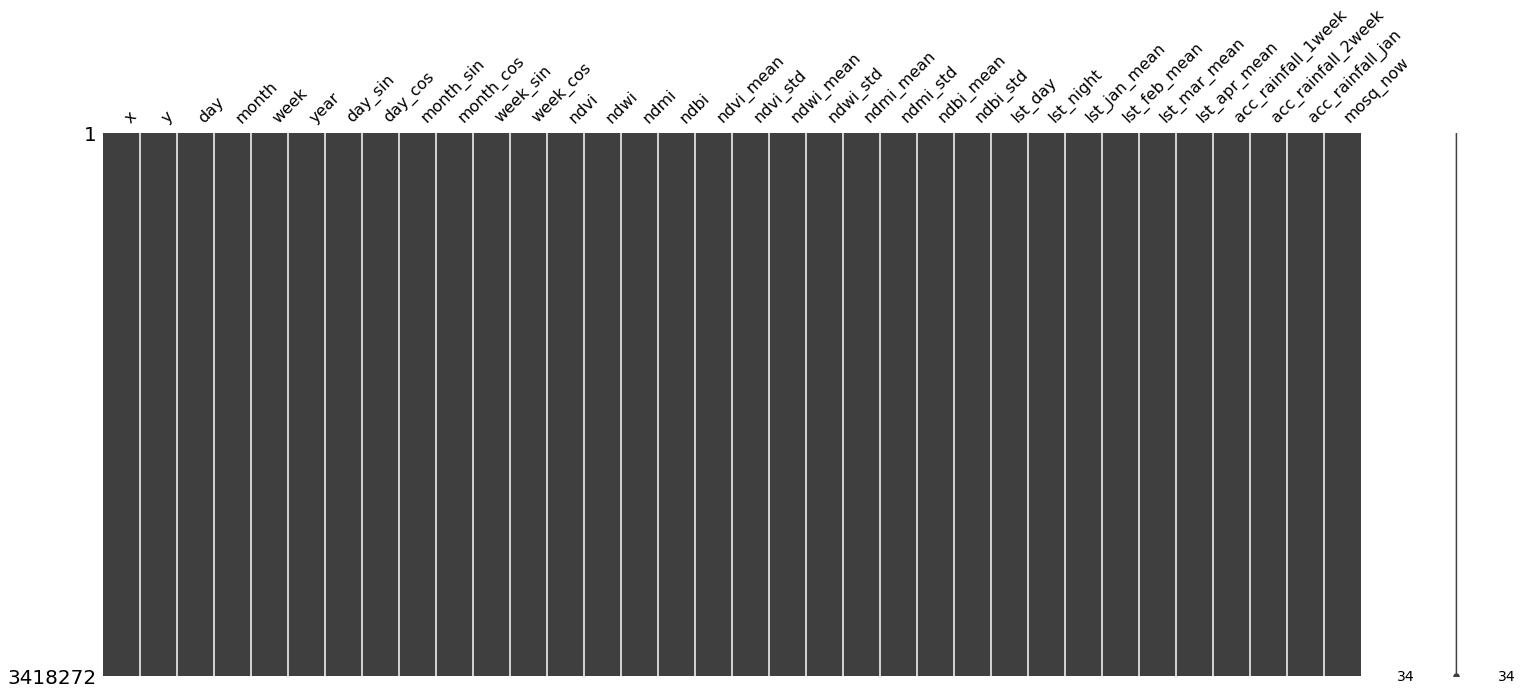

In [20]:
missingno.matrix(dataset_mamoth)

In [21]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [22]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [23]:
predictions = give_predictions(model, dataset_mamoth)

In [24]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.925360,36.229230,2009-01-01,239
1,22.925360,36.229230,2009-01-02,239
2,22.925360,36.229230,2009-01-03,244
3,22.925360,36.229230,2009-01-04,66
4,22.925360,36.229230,2009-01-05,9
...,...,...,...,...
3418267,24.052650,37.796350,2023-12-27,44
3418268,24.052650,37.796350,2023-12-28,43
3418269,24.052650,37.796350,2023-12-29,41
3418270,24.052650,37.796350,2023-12-30,40


<AxesSubplot:>

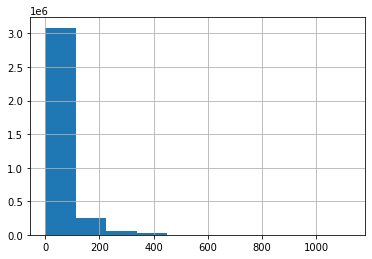

In [25]:
mosqutio_predictions.mosq_pred.hist()

In [26]:
#mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc, index = False)

mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

dataset = timeline_file

In [27]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [28]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14129.000000,13991.000000,14129.000000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,0.000000,14060.000000,14060.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,239
1,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.500000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,3.562209,14060.500000,14060.250000,NaN,NaN,NaN,3.562209,3.562209,3.562209,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,239
2,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.666667,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,9.715884,14060.500000,14060.333333,NaN,NaN,NaN,13.278093,13.278093,13.278093,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,244
3,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.750000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,74.676221,14060.500000,14060.375000,NaN,NaN,NaN,87.954314,87.954314,87.954314,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,66
4,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.800000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,176.860980,14060.500000,14060.400000,NaN,NaN,NaN,264.815294,264.815294,264.815294,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3418267,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2023-12-27,2023,12,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14388.645161,14331.642857,14535.354839,14535.354839,14071.258065,13965.321429,14092.129032,14092.129032,NaN,NaN,14229.951613,14148.482143,14313.741935,14313.741935,0.000000,0.000000,414.909292,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,44
3418268,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2023-12-28,2023,12,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14388.645161,14331.642857,14535.354839,14535.354839,14071.258065,13965.321429,14092.129032,14092.129032,NaN,NaN,14229.951613,14148.482143,14313.741935,14313.741935,0.000000,0.000000,414.909292,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,43
3418269,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2023-12-29,2023,12,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14388.645161,14331.642857,14535.354839,14535.354839,14071.258065,13965.321429,14092.129032,14092.129032,NaN,NaN,14229.951613,14148.482143,14313.741935,14313.741935,0.000000,0.000000,414.909292,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,41
3418270,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2023-12-30,2023,12,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14388.645161,14331.642857,14535.354839,14535.354839,14071.258065,13965.321429,14092.129032,14092.129032,NaN,NaN,14229.951613,14148.482143,14313.741935,14313.741935,0.000000,0.000000,414.909292,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,40


In [29]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [30]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [31]:
dataset_locations

,x,y
0,22.925360,36.229230
1,22.925360,36.319060
2,22.925360,36.337030
3,22.947520,36.193290
4,22.947520,36.193290
...,...,...
629,24.029960,38.173650
630,24.029960,38.191620
631,24.052650,37.760420
632,24.052650,37.778380


In [32]:
dataset_locations_per_year

,x,y,year
0,22.925360,36.229230,2009
1,22.925360,36.229230,2010
2,22.925360,36.229230,2011
3,22.925360,36.229230,2012
4,22.925360,36.229230,2013
...,...,...,...
9355,24.052650,37.796350,2019
9356,24.052650,37.796350,2020
9357,24.052650,37.796350,2021
9358,24.052650,37.796350,2022


In [33]:
geomorphological = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [34]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.010615687744791717
Max distance: 43.94349542727878


In [35]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [36]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1766.939816,1601.841062,4,246.931308,294.282271,188.896356,0.000000,13.807318
1,22.925360,36.319060,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
2,22.925360,36.337030,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
3,22.947520,36.193290,3356.331183,1568.472969,4,239.051151,320.435120,175.997834,0.000000,12.286752
4,22.947520,36.193290,3356.331183,1568.472969,4,239.051151,320.435120,175.997834,0.000000,12.286752
...,...,...,...,...,...,...,...,...,...,...
629,24.029960,38.173650,2219.864897,704.878405,3,164.261290,10.281783,176.088228,0.000000,8.023129
630,24.029960,38.191620,1564.679149,3926.293406,16,78.273691,93.872007,172.002504,0.000000,1.987891
631,24.052650,37.760420,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373
632,24.052650,37.778380,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373


In [37]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [38]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1766.939816,1601.841062,4,246.931308,294.282271,188.896356,0.000000,13.807318
1,22.925360,36.319060,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
2,22.925360,36.337030,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
3,22.947520,36.193290,3356.331183,1568.472969,4,239.051151,320.435120,175.997834,0.000000,12.286752
4,22.947520,36.193290,3356.331183,1568.472969,4,239.051151,320.435120,175.997834,0.000000,12.286752
...,...,...,...,...,...,...,...,...,...,...
629,24.029960,38.173650,2219.864897,704.878405,3,164.261290,10.281783,176.088228,0.000000,8.023129
630,24.029960,38.191620,1564.679149,3926.293406,16,78.273691,93.872007,172.002504,0.000000,1.987891
631,24.052650,37.760420,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373
632,24.052650,37.778380,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373


In [41]:
landcover = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [42]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [43]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [44]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [45]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [46]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2010
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2011
Min distance: 0.010615687744791717
Max distance: 43.94349542727878
Year: 2012
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2013
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2014
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2015
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2016
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2017
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2018
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2019
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2020
Min distance: 0.010615687744791717
Max distance: 43.943495427278236
Year: 2021
Min distance: 0.010615687744791717
Max dis

In [47]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [48]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.925360,36.229230,2009,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
1,22.925360,36.319060,2009,22,83,20,83.000000,20,83,9,9,4,1,1,2,0
2,22.925360,36.337030,2009,22,83,20,83.000000,20,83,9,9,4,1,1,2,0
3,22.947520,36.193290,2009,22,95,20,95.000000,20,95,9,9,4,2,2,2,0
4,22.947520,36.211260,2009,22,74,20,74.000000,20,74,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9355,24.029960,38.173650,2023,22,81,20,81.000000,20,81,9,9,4,2,2,2,0
9356,24.029960,38.191620,2023,31,87,30,87.000000,30,87,10,10,1,6,6,2,0
9357,24.052650,37.760420,2023,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
9358,24.052650,37.778380,2023,31,92,30,92.000000,30,92,10,10,1,6,6,2,0


In [49]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [50]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [51]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [52]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14129.000000,13991.000000,14129.000000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,0.000000,14060.000000,14060.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,239,1766.939816,1601.841062,4,246.931308,294.282271,188.896356,0.000000,13.807318,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
1,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.500000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,3.562209,14060.500000,14060.250000,NaN,NaN,NaN,3.562209,3.562209,3.562209,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,239,1766.939816,1601.841062,4,246.931308,294.282271,188.896356,0.000000,13.807318,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
2,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.666667,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,9.715884,14060.500000,14060.333333,NaN,NaN,NaN,13.278093,13.278093,13.278093,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,244,1766.939816,1601.841062,4,246.931308,294.282271,188.896356,0.000000,13.807318,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
3,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.750000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,74.676221,14060.500000,14060.375000,NaN,NaN,NaN,87.954314,87.954314,87.954314,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,66,1766.939816,1601.841062,4,246.931308,294.282271,188.896356,0.000000,13.807318,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
4,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14130.000000,13991.000000,14129.800000,NaN,NaN,NaN,13991.000000,NaN,NaN,NaN,176.860980,14060.500000,14060.400000,NaN,NaN,NaN,264.815294,264.815294,264.815294,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,9,1766.939816,1601.841062,4,246.931308,294.282271,188.896356,0.000000,13.807318,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3418267,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2023-12-27,2023,12,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14388.645161,14331.642857,14535.354839,14535.354839,14071.258065,13965.321429,14092.129032,14092.129032,NaN,NaN,14229.951613,14148.482143,14313.741935,14313.741935,0.000000,0.000000,414.909292,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,44,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
3418268,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2023-12-28,2023,12,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [53]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [54]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [55]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [56]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [57]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [58]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.800770,38.054770,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14081.000000,13762.000000,14081.000000,NaN,NaN,NaN,13762.000000,NaN,NaN,NaN,0.479960,13936.000000,13936.000000,NaN,NaN,NaN,0.479960,0.479960,0.479960,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,18,9160.777000,292.022047,2,182.342684,228.131012,182.543294,0.000000,1.047122,32,97,9,99.000000,30,97,13,13,10,8,9,2,0
1,2009-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.681940,38.021300,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14128.000000,13875.000000,14128.000000,NaN,NaN,NaN,13875.000000,NaN,NaN,NaN,0.000000,14014.500000,14014.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,73,7655.023708,1575.096836,1,173.398830,66.866135,178.818040,0.000000,5.887334,1,98,9,99.000000,1,98,13,13,10,8,9,2,0
2,2009-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.743860,37.962720,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13912.000000,13857.000000,13912.000000,NaN,NaN,NaN,13857.000000,NaN,NaN,NaN,0.000000,13962.500000,13962.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,85,6716.989270,1493.626330,2,197.255841,68.539566,184.962678,0.000000,1.629068,1,88,9,98.000000,1,88,13,13,10,8,9,2,0
3,2009-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.729110,37.880760,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14101.000000,13948.000000,14101.000000,NaN,NaN,NaN,13948.000000,NaN,NaN,NaN,0.000000,14035.500000,14035.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,97,2801.690321,1232.926967,4,211.997473,80.771234,191.138144,0.000000,1.000000,32,97,9,99.000000,30,97,13,13,10,8,9,2,0
4,2009-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.961890,38.155680,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14057.000000,13728.000000,14057.000000,NaN,NaN,NaN,13728.000000,NaN,NaN,NaN,0.000000,13955.500000,13955.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,17,4717.525174,2045.158360,5,274.644451,270.182396,181.821244,0.000000,1.000000,31,98,30,86.000000,30,98,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38341,2023-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.743860,37.962720,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14187.516129,14081.571429,14418.935484,14418.935484,13957.129032,13847.857143,14022.967742,14022.967742,NaN,NaN,14072.322581,13964.714286,14220.951613,14220.951613,0.000000,0.000000,473.979882,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,17,6716.989270,1493.626330,2,197.255841,68.539566,184.962678,0.000000,1.629068,1,92,9,98.000000,1,92,13,13,10,8,9,2,0
38342,2023-12-31,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.729110,37.880760,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [59]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.777980,38.018840,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14033.000000,13751.000000,14033.000000,NaN,NaN,NaN,13751.000000,NaN,NaN,NaN,0.000000,13897.500000,13897.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,18,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,22,75,9,75.000000,20,75,9,9,4,1,1,2,0
1,2009-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.659150,38.003330,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14128.000000,13875.000000,14128.000000,NaN,NaN,NaN,13875.000000,NaN,NaN,NaN,0.000000,14014.500000,14014.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,71,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,1,91,9,71.000000,1,91,13,13,10,8,9,2,0
2,2009-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.721090,37.944760,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13912.000000,13857.000000,13912.000000,NaN,NaN,NaN,13857.000000,NaN,NaN,NaN,0.000000,13962.500000,13962.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,23,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,1,69,9,84.000000,1,69,10,10,1,6,6,2,0
3,2009-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.706360,37.880760,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14101.000000,13948.000000,14101.000000,NaN,NaN,NaN,13948.000000,NaN,NaN,NaN,0.000000,14035.500000,14035.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,77,1040.862914,750.449832,4,157.523373,23.000401,182.333272,0.000000,1.000000,1,83,9,98.000000,1,83,13,13,10,8,9,2,0
4,2009-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.666920,37.670580,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13553.000000,13597.000000,13553.000000,NaN,NaN,NaN,13597.000000,NaN,NaN,NaN,0.000000,13665.000000,13665.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,4,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,11,71,9,71.000000,10,56,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38341,2023-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.721090,37.944760,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14187.516129,14081.571429,14418.935484,14418.935484,13957.129032,13847.857143,14022.967742,14022.967742,NaN,NaN,14072.322581,13964.714286,14220.951613,14220.951613,0.000000,0.000000,473.979882,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,17,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,1,68,9,75.000000,1,68,1,1,7,1,1,2,0
38342,2023-12-31,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.706360,37.880760,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [60]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_night','lst', 'rainfall','mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [61]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2009-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14089.066667,13805.066667,13947.066667,0.438444,29.533333,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2
1,2009-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14145.400000,13901.200000,14023.300000,0.000000,74.200000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2
2,2009-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14107.900000,13928.888889,14029.277778,0.000000,68.800000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2
3,2009-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14153.571429,13967.142857,14060.357143,0.000000,89.142857,3119.148817,1482.800388,9.571429,209.850214,142.375849,193.389493,0.000000,3.329157,1040.862914,750.449832,4,157.523373,23.000401,182.333272,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1795.407611,614.878766,6.051367,32.059693,138.259736,11.563001,0.000000,3.423209,32,9,30,13,13,10,8,9,2
4,2009-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14060.965812,13761.641593,13914.170455,0.198145,55.498316,5675.737458,2291.424751,9.178451,170.080941,278.088849,177.414457,0.000000,4.047466,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3379.688271,935.441500,5.899938,54.713488,206.313314,9.705228,0.000000,3.999820,31,30,30,10,10,1,6,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38341,2023-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,31,12,2023,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

<AxesSubplot:>

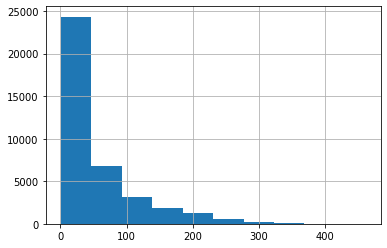

In [62]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [63]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<AxesSubplot:>

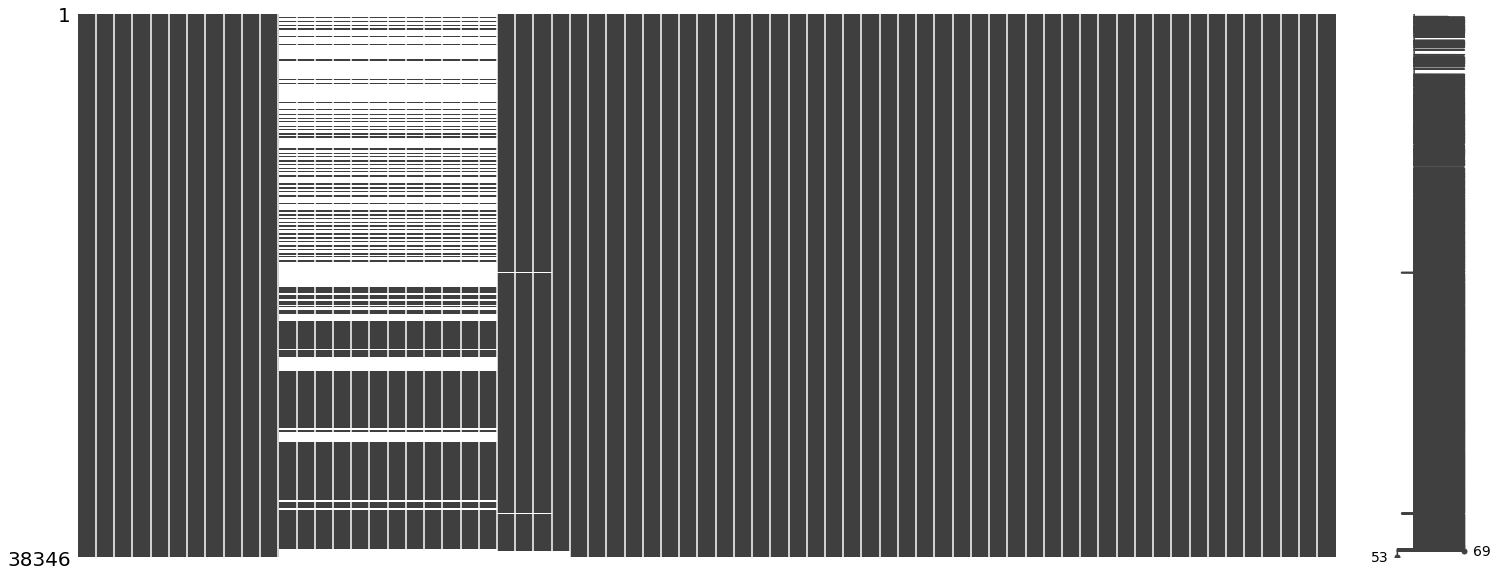

In [64]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [65]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [66]:
bio_values_df = pd.DataFrame(bio_values)

In [67]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,βορειος τομεας αθηνων,2009,1,1.978000,14.480667,194.912970
1,βορειος τομεας αθηνων,2009,2,0.584667,14.726000,125.779597
2,βορειος τομεας αθηνων,2009,3,2.708667,20.975333,147.885706
3,βορειος τομεας αθηνων,2009,4,8.576667,28.066000,58.404979
4,βορειος τομεας αθηνων,2009,5,11.208667,36.494000,34.249590
...,...,...,...,...,...,...
1255,"πειραιας, νησοι",2023,8,22.604141,38.823939,1.916161
1256,"πειραιας, νησοι",2023,9,17.981515,32.704737,136.469335
1257,"πειραιας, νησοι",2023,10,15.820505,27.308384,1.388495
1258,"πειραιας, νησοι",2023,11,NaN,NaN,0.000000


In [68]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [69]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.631333,2.951333,5.791333,0.438444,29.533333,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2,1.978000,14.480667,194.912970
1,2009-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.758000,4.874000,7.316000,0.000000,74.200000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567
2,2009-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.008000,5.427778,7.217889,0.000000,68.800000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674
3,2009-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.921429,6.192857,8.057143,0.000000,89.142857,3119.148817,1482.800388,9.571429,209.850214,142.375849,193.389493,0.000000,3.329157,1040.862914,750.449832,4,157.523373,23.000401,182.333272,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1795.407611,614.878766,6.051367,32.059693,138.259736,11.563001,0.000000,3.423209,32,9,30,13,13,10,8,9,2,3.404286,16.027143,193.915020
4,2009-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.069316,2.082832,5.076074,0.198145,55.498316,5675.737458,2291.424751,9.178451,170.080941,278.088849,177.414457,0.000000,4.047466,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3379.688271,935.441500,5.899938,54.713488,206.313314,9.705228,0.000000,3.999820,31,30,30,10,10,1,6,6,2,2.082832,14.696869,191.736680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

<AxesSubplot:>

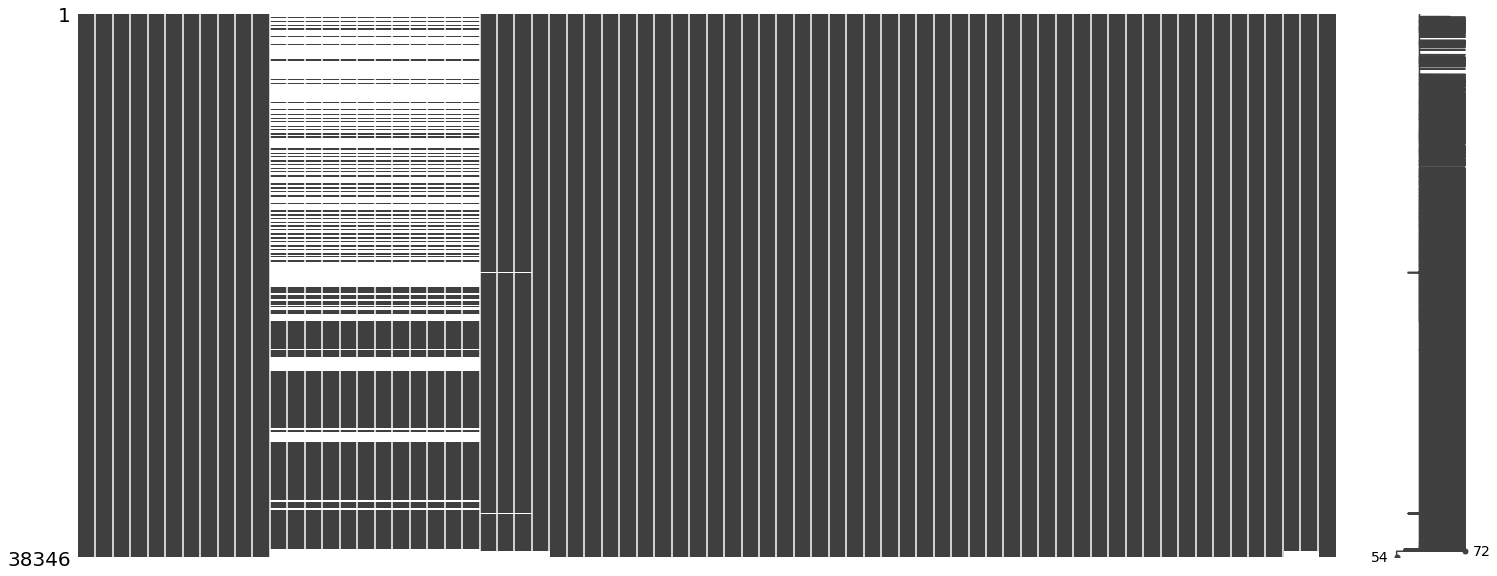

In [70]:
missingno.matrix(dataset)

In [71]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [72]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [73]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2009-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.631333,2.951333,5.791333,0.438444,29.533333,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2,1.978000,14.480667,194.912970,2009-01
1,2009-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.758000,4.874000,7.316000,0.000000,74.200000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567,2009-01
2,2009-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.008000,5.427778,7.217889,0.000000,68.800000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674,2009-01
3,2009-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.921429,6.192857,8.057143,0.000000,89.142857,3119.148817,1482.800388,9.571429,209.850214,142.375849,193.389493,0.000000,3.329157,1040.862914,750.449832,4,157.523373,23.000401,182.333272,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1795.407611,614.878766,6.051367,32.059693,138.259736,11.563001,0.000000,3.423209,32,9,30,13,13,10,8,9,2,3.404286,16.027143,193.915020,2009-01
4,2009-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.069316,2.082832,5.076074,0.198145,55.498316,5675.737458,2291.424751,9.178451,170.080941,278.088849,177.414457,0.000000,4.047466,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3379.688271,935.441500,5.899938,54.713488,206.313314,9.705228,0.000000,3.999820,31,30,30,10,10,1,6,6,2,2.082832,14.696869,191.736680,2009-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [74]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.631333,7.632667,5.791333,0.003903,26.000000,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2,1.978000,14.480667,194.912970
1,1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.758000,9.910000,7.316000,0.000000,34.800000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567
2,2,2009-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.008000,5.427778,7.217889,0.000000,47.800000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674
3,3,2009-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.921429,6.192857,8.057143,0.000000,32.714286,3119.148817,1482.800388,9.571429,209.850214,142.375849,193.389493,0.000000,3.329157,1040.862914,750.449832,4,157.523373,23.000401,182.333272,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1795.407611,614.878766,6.051367,32.059693,138.259736,11.563001,0.000000,3.423209,32,9,30,13,13,10,8,9,2,3.404286,16.027143,193.915020
4,4,2009-01,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,1,1,2009,2,NaN,NaN,NaN,NaN,-0.031678,0.613446,0.648602,-0.613446,0.000000,0.000000,0.000000,0.000000,7.993207,2.082832,5.038019,0.024464,32.020202,5675.737458,2291.424751,9.178451,170.080941,278.088849,177.414457,0.000000,4.047466,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3379.688271,935.441500,5.899938,54.713488,206.313314,9.705228,0.000000,3.999820,31,30,30,10,10,1,6,6,2,2.082832,14.696869,191.736680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [75]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_month_mean[['x','y']],
                                     grouped_by_month_mods[['month','year']],
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std','lst_day','lst_night','lst','rainfall']],
                                     grouped_by_month_sum[['mosq_pred']],
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [76]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845785,5.512796,8.179290,6.287515,892.266667,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2,1.978000,14.480667,194.912970
1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446903,7.663290,9.555097,6.327663,1331.400000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567
2,2009-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.370194,7.741384,9.555789,6.287377,1227.100000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674
3,2009-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.343641,7.688249,10.015945,6.255323,1558.571429,3119.148817,1482.800388,9.571429,209.850214,142.375849,193.389493,0.000000,3.329157,1040.862914,750.449832,4,157.523373,23.000401,182.333272,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1795.407611,614.878766,6.051367,32.059693,138.259736,11.563001,0.000000,3.423209,32,9,30,13,13,10,8,9,2,3.404286,16.027143,193.915020
4,2009-01,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,1,2009,NaN,NaN,NaN,NaN,-0.031678,0.613446,0.648602,-0.613446,0.000000,0.000000,0.000000,0.000000,10.736874,5.197532,7.967203,6.185054,1034.690236,5675.737458,2291.424751,9.178451,170.080941,278.088849,177.414457,0.000000,4.047466,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3379.688271,935.441500,5.899938,54.713488,206.313314,9.705228,0.000000,3.999820,31,30,30,10,10,1,6,6,2,2.082832,14.696869,191.736680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [91]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5


In [92]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1260 non-null   period[M]
 1   NUTS2_ID                1260 non-null   object   
 2   NUTS2_NAME              1260 non-null   object   
 3   NUTS3_ID                1260 non-null   object   
 4   NUTS3_NAME              1260 non-null   object   
 5   x                       1260 non-null   float64  
 6   y                       1260 non-null   float64  
 7   month                   1260 non-null   int64    
 8   year                    1260 non-null   int64    
 9   ndvi                    1213 non-null   float64  
 10  ndmi                    1213 non-null   float64  
 11  ndwi                    1213 non-null   float64  
 12  ndbi                    1213 non-null   float64  
 13  ndvi_mean               1217 non-null   float64  
 14  ndmi_mea

In [93]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    336 non-null    object
 1   NUTS3_NAME    336 non-null    object
 2   dt_placement  336 non-null    object
 3   cases         336 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 10.6+ KB


In [94]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [95]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5
...,...,...,...,...
331,αττικη,"πειραιας, νησοι",2021-06,0
332,αττικη,"πειραιας, νησοι",2021-07,0
333,αττικη,"πειραιας, νησοι",2021-08,0
334,αττικη,"πειραιας, νησοι",2021-09,0


In [96]:
wnv_file['cases'].value_counts()

0     269
1      35
4       5
8       4
5       4
7       3
2       3
6       2
3       2
11      1
15      1
10      1
18      1
16      1
12      1
33      1
9       1
20      1
Name: cases, dtype: int64

In [97]:
wnv_file.cases.sum()

296

In [98]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5
...,...,...,...,...
331,αττικη,"πειραιας, νησοι",2021-06,0
332,αττικη,"πειραιας, νησοι",2021-07,0
333,αττικη,"πειραιας, νησοι",2021-08,0
334,αττικη,"πειραιας, νησοι",2021-09,0


In [99]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [100]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845785,5.512796,8.179290,6.287515,892.266667,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2,1.978000,14.480667,194.912970,NaN
1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446903,7.663290,9.555097,6.327663,1331.400000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567,NaN
2,2009-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.370194,7.741384,9.555789,6.287377,1227.100000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674,NaN
3,2009-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.343641,7.688249,10.015945,6.255323,1558.571429,3119.148817,1482.800388,9.571429,209.850214,142.375849,193.389493,0.000000,3.329157,1040.862914,750.449832,4,157.523373,23.000401,182.333272,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1795.407611,614.878766,6.051367,32.059693,138.259736,11.563001,0.000000,3.423209,32,9,30,13,13,10,8,9,2,3.404286,16.027143,193.915020,NaN
4,2009-01,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,1,2009,NaN,NaN,NaN,NaN,-0.031678,0.613446,0.648602,-0.613446,0.000000,0.000000,0.000000,0.000000,10.736874,5.197532,7.967203,6.185054,1034.690236,5675.737458,2291.424751,9.178451,170.080941,278.088849,177.414457,0.000000,4.047466,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3379.688271,935.441500,5.899938,54.713488,206.313314,9.705228,0.000000,3.999820,31,30,30,10,10,1,6,6,2,2.082832,14.696869,191.736680,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [101]:
merged = fillna(merged,{'cases': 0})

In [102]:
merged['cases'].value_counts()

0.000000     1193
1.000000       35
4.000000        5
8.000000        4
5.000000        4
7.000000        3
2.000000        3
6.000000        2
3.000000        2
10.000000       1
33.000000       1
18.000000       1
9.000000        1
16.000000       1
20.000000       1
15.000000       1
12.000000       1
11.000000       1
Name: cases, dtype: int64

In [103]:
merged.cases.sum()

296.0

In [104]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

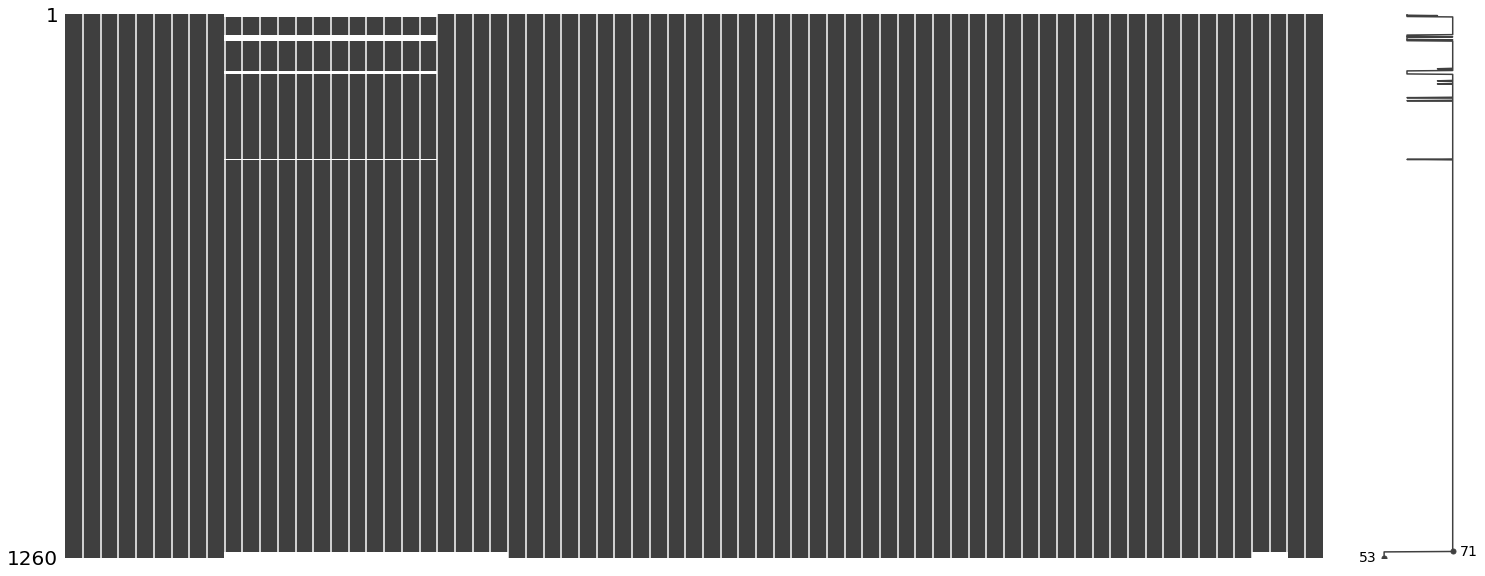

In [105]:
missingno.matrix(merged)

In [106]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

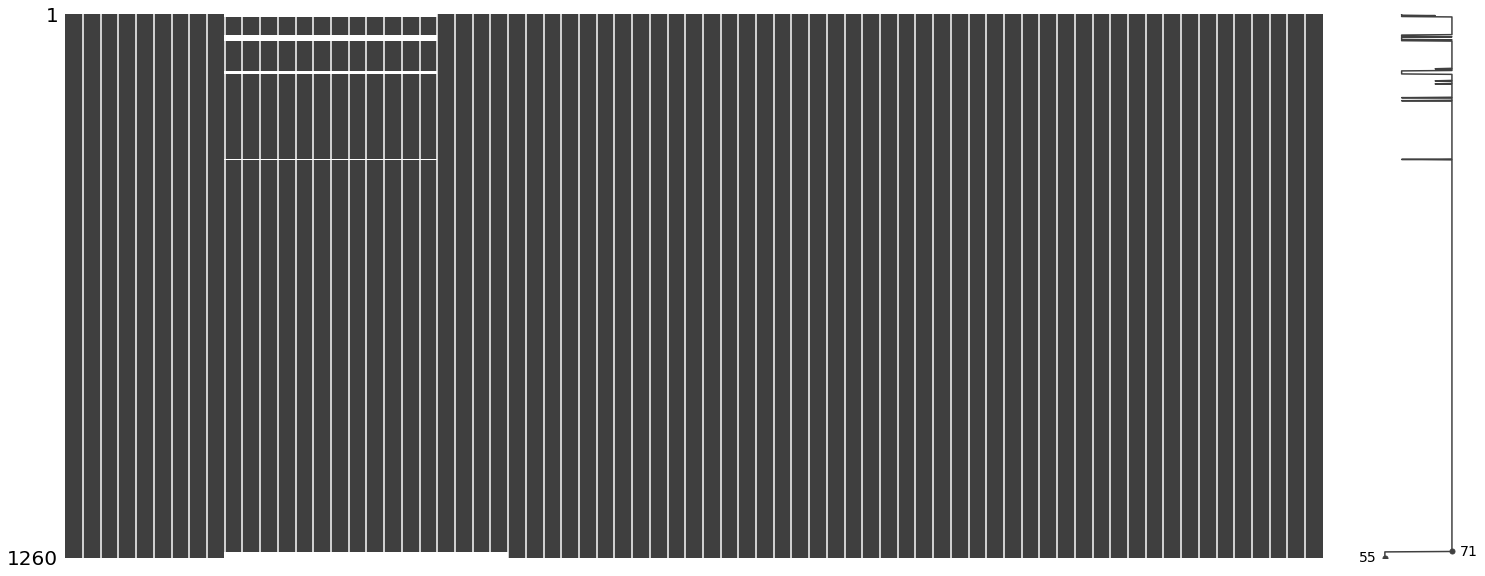

In [107]:
missingno.matrix(merged)

In [108]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023], dtype=int64)

In [109]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['βορειος τομεας αθηνων', 'δυτικος τομεας αθηνων',
       'κεντρικος τομεας αθηνων', 'νοτιος τομεας αθηνων',
       'ανατολικη αττικη', 'δυτικη αττικη', 'πειραιας, νησοι'],
      dtype=object)

In [110]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [111]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,βορειος τομεας αθηνων,2009,19.000000,19.166667,42.592593,920.721061,45.000000,0.000000,45.000000,8.333333,30.666667,30.666667,8.333333,1230.000000,227.000000,9.000000,72.351252,546.000000,54.000000,54.000000,546.000000
1,δυτικος τομεας αθηνων,2009,20.791667,18.916667,42.992424,928.453830,46.000000,2.000000,44.000000,9.833333,33.000000,33.000000,9.833333,1216.000000,229.000000,10.000000,72.746381,538.000000,55.000000,55.000000,538.000000
2,κεντρικος τομεας αθηνων,2009,19.875000,18.250000,43.452381,879.081390,44.000000,2.000000,42.000000,9.833333,31.333333,31.333333,9.833333,1175.000000,208.000000,5.000000,73.228177,521.000000,47.000000,47.000000,521.000000
3,νοτιος τομεας αθηνων,2009,19.291667,18.250000,42.441860,874.761872,43.000000,0.000000,43.000000,9.666667,30.666667,30.666667,9.333333,1156.000000,200.000000,3.000000,74.022313,512.000000,41.000000,41.000000,456.000000
4,ανατολικη αττικη,2009,18.708333,19.916667,44.259259,885.093301,45.000000,0.000000,45.000000,9.000000,29.833333,29.833333,8.333333,1231.000000,223.000000,7.000000,72.756797,539.000000,47.000000,47.000000,467.000000
5,δυτικη αττικη,2009,18.000000,19.833333,43.115942,903.779941,46.000000,0.000000,46.000000,8.000000,30.000000,30.000000,7.833333,1215.000000,212.000000,10.000000,72.952172,530.000000,50.000000,50.000000,461.000000
6,"πειραιας, νησοι",2009,19.000000,17.166667,40.873016,818.257572,44.000000,2.000000,42.000000,15.500000,29.333333,29.333333,9.666667,1748.000000,380.000000,9.000000,83.752614,823.000000,54.000000,54.000000,594.000000
7,βορειος τομεας αθηνων,2010,19.750000,20.333333,46.212121,866.943429,44.000000,0.000000,44.000000,14.666667,31.000000,31.000000,9.333333,847.000000,215.000000,0.000000,84.129929,349.000000,71.000000,71.000000,334.000000
8,δυτικος τομεας αθηνων,2010,21.333333,20.500000,45.555556,904.868984,46.000000,1.000000,45.000000,15.500000,33.000000,33.000000,10.500000,815.000000,206.000000,0.000000,83.186157,329.000000,63.000000,63.000000,311.000000
9,κεντρικος τομεας αθηνων,2010,20.500000,19.500000,44.318182,858.910515,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,10.000000,790.000000,196.000000,0.000000,85.848911,320.000000,50.000000,50.000000,319.000000


In [112]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [113]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'δυτικη αττικη')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
89,2010-01,EL30,αττικη,EL306,δυτικη αττικη,23.395319,38.091064,1,2010,0.352307,0.146017,-0.172538,-0.146017,0.354575,0.151887,-0.167146,-0.151887,0.051064,0.041075,0.042660,0.041075,10.571686,4.495992,7.533839,3.644620,2322.392670,7642.025404,2102.632671,12.020942,159.316224,446.223787,177.887458,0.000000,4.167697,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3777.047079,909.776939,6.317859,46.182671,237.999042,8.058894,0.000000,6.448443,31,30,30,10,10,1,6,6,2,-0.222880,18.099738,112.983220,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,845.000000,217.000000,0.000000,82.111607,343.000000,63.000000,63.000000,302.000000
96,2010-02,EL30,αττικη,EL306,δυτικη αττικη,23.395319,38.091064,2,2010,0.308002,0.081885,-0.216865,-0.081885,0.302355,0.083829,-0.211749,-0.083829,0.022534,0.013486,0.016906,0.013486,12.442349,5.499637,8.970993,4.178371,468.293194,7642.025404,2102.632671,12.020942,159.316224,446.223787,177.887458,0.000000,4.167697,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3777.047079,909.776939,6.317859,46.182671,237.999042,8.058894,0.000000,6.448443,31,30,30,10,10,1,6,6,2,-0.572408,17.531152,116.994377,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,845.000000,217.000000,0.000000,82.111607,343.000000,63.000000,63.000000,302.000000
103,2010-03,EL30,αττικη,EL306,δυτικη αττικη,23.395319,38.091064,3,2010,0.364360,0.086210,-0.286182,-0.086210,0.365652,0.087714,-0.285055,-0.087714,0.032457,0.029587,0.026168,0.029587,17.713476,7.852050,12.782763,2.326300,1110.340314,7642.025404,2102.632671,12.020942,159.316224,446.223787,177.887458,0.000000,4.167697,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3777.047079,909.776939,6.317859,46.182671,237.999042,8.058894,0.000000,6.448443,31,30,30,10,10,1,6,6,2,3.686440,22.778901,72.115311,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,845.000000,217.000000,0.000000,82.111607,343.000000,63.000000,63.000000,302.000000
110,2010-04,EL30,αττικη,EL306,δυτικη αττικη,23.395319,38.091064,4,2010,0.403342,0.109944,-0.291336,-0.109944,0.403536,0.109321,-0.292822,-0.109321,0.033763,0.036626,0.030090,0.036626,21.910077,9.036087,15.473082,0.427415,2415.968586,7642.025404,2102.632671,12.020942,159.316224,446.223787,177.887458,0.000000,4.167697,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3777.047079,909.776939,6.317859,46.182671,237.999042,8.058894,0.00

In [114]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [115]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [116]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [117]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [118]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

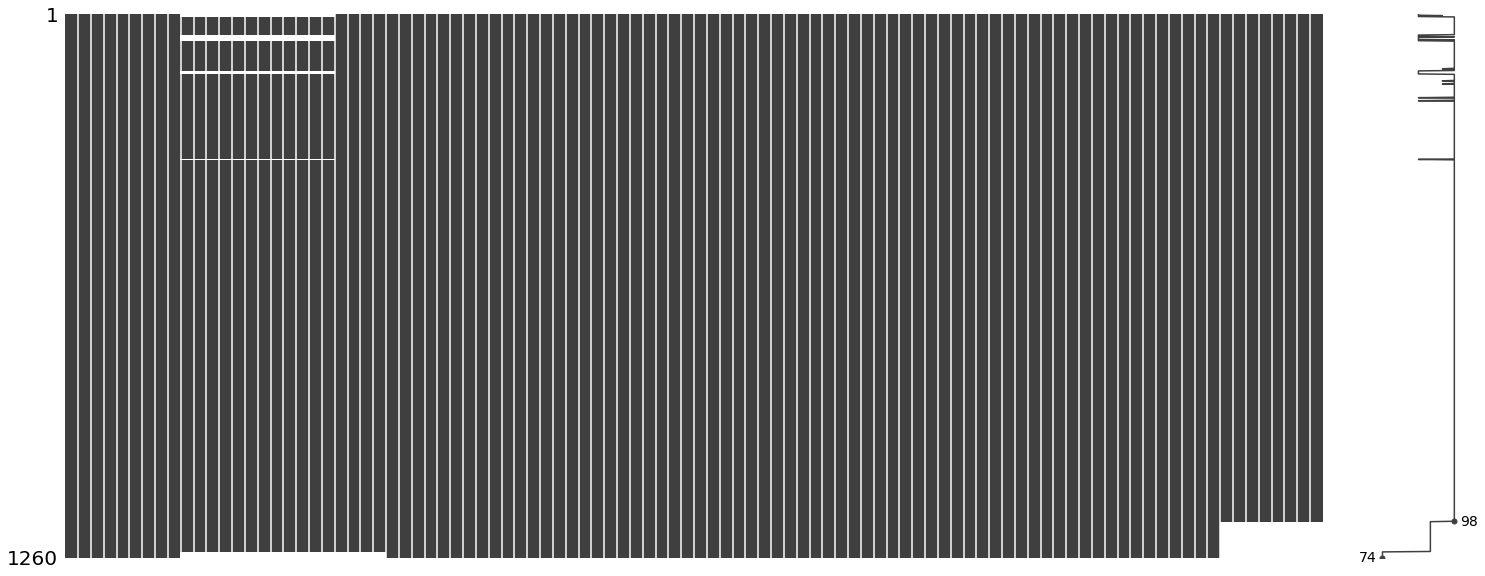

In [119]:
missingno.matrix(dataset)

In [120]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [121]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [122]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [123]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [124]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

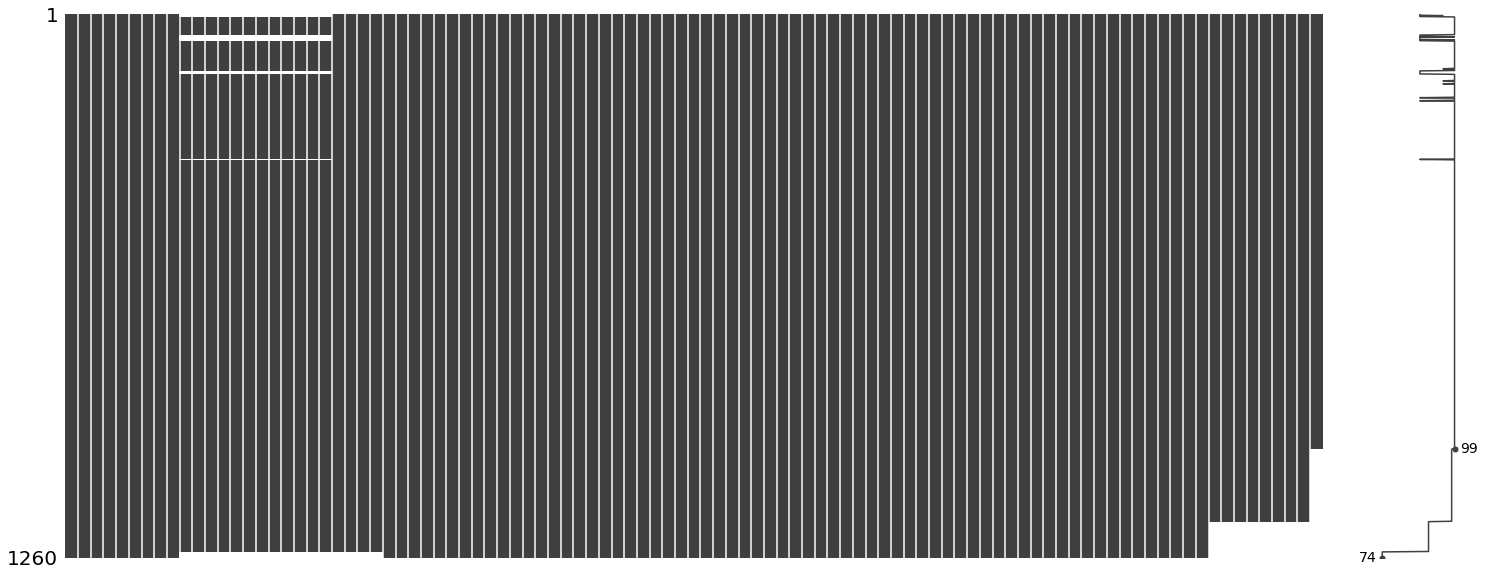

In [125]:
missingno.matrix(dataset)

In [126]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [127]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [128]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [129]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [130]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

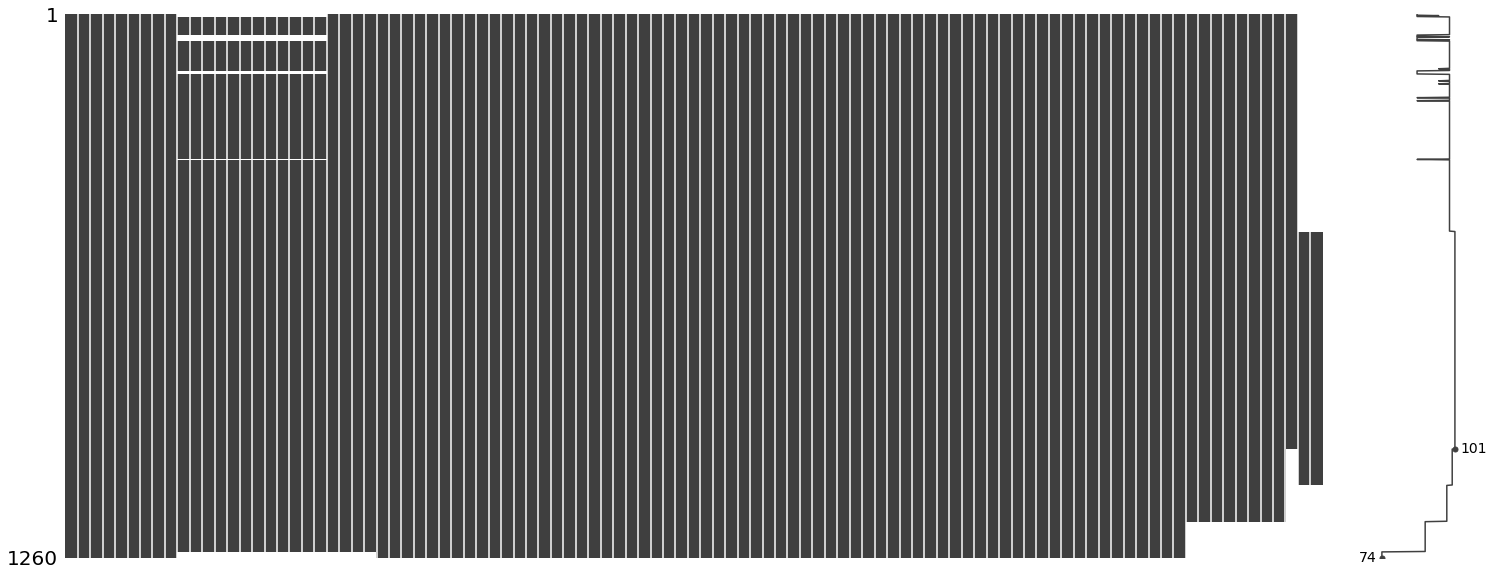

In [131]:
missingno.matrix(dataset)

In [132]:
missing = describe_dataframe(dataset)

In [133]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
96,F_Y_GE65,6.666700
97,F_TOTAL,6.666700
98,MIO_EUR,20.000000
99,L_TOTAL,53.333300


In [134]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845785,5.512796,8.179290,6.287515,892.266667,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2,1.978000,14.480667,194.912970,0,19.000000,19.166667,42.592593,920.721061,45.000000,0.000000,45.000000,8.333333,30.666667,30.666667,8.333333,1230.000000,227.000000,9.000000,72.351252,546.000000,54.000000,54.000000,546.000000,45632.000000,201617.000000,45952.000000,293201.000000,43321.000000,220852.000000,58521.000000,322694.000000,19823.630000,NaN,NaN
1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446903,7.663290,9.555097,6.327663,1331.400000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567,0,20.791667,18.916667,42.992424,928.453830,46.000000,2.000000,44.000000,9.833333,33.000000,33.000000,9.833333,1216.000000,229.000000,10.000000,72.746381,538.000000,55.000000,55.000000,538.000000,39132.000000,180473.000000,33120.000000,252725.000000,36806.000000,177964.000000,43801.000000,258571.000000,7725.120000,NaN,NaN
2,2009-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.370194,7.741384,9.555789,6.287377,1227.100000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674,0,19.875000,18.250000,43.452381,879.081390,44.000000,2.000000,42.000000,9.833333,31.333333,31.333333,9.833333,1175.000000,208.000000,5.000000,73.228177,521.000000,47.000000,47.000000,521.000000,65801.000000,384275.000000,78826.000000,528902.000000,62294.000000,394771.000000,118140.000000,575205.000000,42230.540000,NaN,NaN
3,2009-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.343641,7.688249,10.015945,6.255323,1558.571429,3119.148817,1482.800388,9.571429,209.850214,142.37

In [135]:
dataset.reset_index(inplace=True, drop=True)

In [136]:
dataset['cases'].value_counts()

0     1193
1       35
4        5
8        4
5        4
7        3
2        3
6        2
3        2
10       1
33       1
18       1
9        1
16       1
20       1
15       1
12       1
11       1
Name: cases, dtype: int64

In [137]:
dataset['cases'].sum()

296

In [138]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845785,5.512796,8.179290,6.287515,892.266667,12747.201464,1542.413505,7.333333,202.119179,315.556339,186.902118,0.000000,10.068240,9160.777000,292.022047,2,143.099324,183.461433,182.266070,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,41.287682,2168.956615,1107.861743,5.777625,36.855672,163.386044,5.880920,0.000000,16.231537,32,9,30,13,13,10,8,9,2,1.978000,14.480667,194.912970,0,19.000000,19.166667,42.592593,920.721061,45.000000,0.000000,45.000000,8.333333,30.666667,30.666667,8.333333,1230.000000,227.000000,9.000000,72.351252,546.000000,54.000000,54.000000,546.000000,45632.000000,201617.000000,45952.000000,293201.000000,43321.000000,220852.000000,58521.000000,322694.000000,19823.630000,NaN,NaN
1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446903,7.663290,9.555097,6.327663,1331.400000,7233.512563,1981.405366,6.000000,157.306266,112.305295,174.291350,0.000000,4.032312,4986.234414,897.594305,1,136.450508,66.866135,167.697476,0.000000,1.730851,9100.860094,3403.889152,17,173.398830,224.284665,178.818040,0.000000,5.887334,1508.893889,968.620541,6.557439,16.246230,64.984151,5.686076,0.000000,1.815019,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567,0,20.791667,18.916667,42.992424,928.453830,46.000000,2.000000,44.000000,9.833333,33.000000,33.000000,9.833333,1216.000000,229.000000,10.000000,72.746381,538.000000,55.000000,55.000000,538.000000,39132.000000,180473.000000,33120.000000,252725.000000,36806.000000,177964.000000,43801.000000,258571.000000,7725.120000,NaN,NaN
2,2009-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.370194,7.741384,9.555789,6.287377,1227.100000,7621.133863,2311.542939,14.700000,210.591408,207.466538,192.110042,0.000637,6.568623,4751.134763,367.040836,2,195.030712,68.539566,184.962678,0.000000,1.000000,10803.720685,3598.481563,31,239.898712,357.544458,202.358896,0.006370,46.574255,1776.322889,1155.293914,12.710888,14.988203,120.300547,6.889556,0.002014,14.070040,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674,0,19.875000,18.250000,43.452381,879.081390,44.000000,2.000000,42.000000,9.833333,31.333333,31.333333,9.833333,1175.000000,208.000000,5.000000,73.228177,521.000000,47.000000,47.000000,521.000000,65801.000000,384275.000000,78826.000000,528902.000000,62294.000000,394771.000000,118140.000000,575205.000000,42230.540000,NaN,NaN
3,2009-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.343641,7.688249,10.015945,6.255323,1558.571429,3119.148817,1482.800388,9.571429,209.850214,142.37

In [139]:
cols = dataset.columns

In [140]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=101)


In [141]:
len(cols)

101

In [142]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc, index = False)
